In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/workspaces/protein-aggregation/genetic_instances/instance1'
all_fitness_data = []
individual_fitness_records = []

In [3]:
for i in range(20):
    file_path = os.path.join(path, f'generation_{i}.json')

    with open(file_path, 'r') as f:
        data = json.load(f)
        fitness_scores = [individual['fitness'] for individual in data['population']]

        if fitness_scores:
            best_fitness = max(fitness_scores)
            avg_fitness = sum(fitness_scores)/len(fitness_scores)
            min_fitness = min(fitness_scores)

            all_fitness_data.append({
                'generation': i,
                'best_fitness': best_fitness,
                'avg_fitness': avg_fitness,
                'min_fitness': min_fitness
            })

        for score in fitness_scores:
            individual_fitness_records.append({
                'generation': i,
                'fitness': score
            })

In [4]:
df_convergence = pd.DataFrame(all_fitness_data)
df_individuals = pd.DataFrame(individual_fitness_records)

In [5]:
print(df_convergence)

    generation  best_fitness  avg_fitness  min_fitness
0            0      0.253382     0.063884     0.023207
1            1      0.253382     0.073947     0.028693
2            2      0.281625     0.087805     0.034442
3            3      0.368180     0.113148     0.022108
4            4      0.368180     0.137083     0.024817
5            5      0.517150     0.197178     0.037078
6            6      0.517150     0.282435     0.035946
7            7      0.517150     0.303319     0.040262
8            8      0.640817     0.363701     0.169361
9            9      0.830723     0.376425     0.011050
10          10      0.861792     0.402012     0.166690
11          11      0.861792     0.419313     0.200094
12          12      0.861792     0.467178     0.249950
13          13      0.942126     0.520868     0.073251
14          14      0.942126     0.593964     0.035448
15          15      0.942126     0.650540     0.146519
16          16      0.986545     0.714325     0.221118
17        

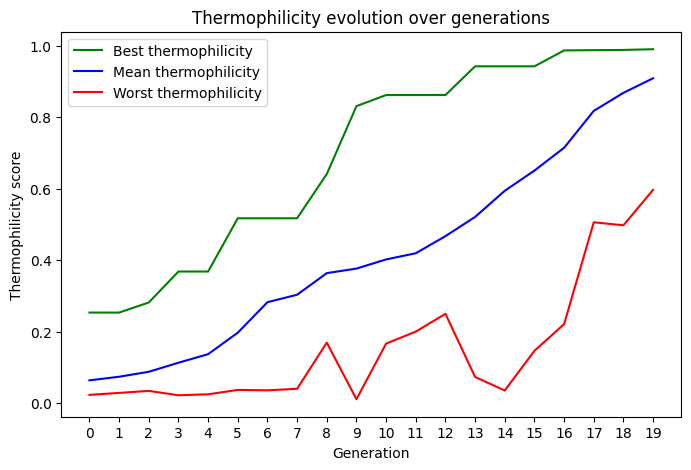

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df_convergence['generation'], df_convergence['best_fitness'], label='Best thermophilicity', color='green',linestyle='-')
plt.plot(df_convergence['generation'], df_convergence['avg_fitness'], label='Mean thermophilicity', color='blue', linestyle='-')
plt.plot(df_convergence['generation'], df_convergence['min_fitness'], label='Worst thermophilicity', color='red', linestyle='-')
plt.title('Thermophilicity evolution over generations')
plt.xlabel('Generation')
plt.ylabel('Thermophilicity score')
plt.legend()
plt.xticks(df_convergence['generation']) # Garante que todos os números
#plt.grid()
plt.show()

In [7]:
generations_to_plot = [0, 4, 9, 14, 19]
df_filtered = df_individuals[df_individuals['generation'].isin(generations_to_plot)]

/tmp/ipykernel_739/1671725610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


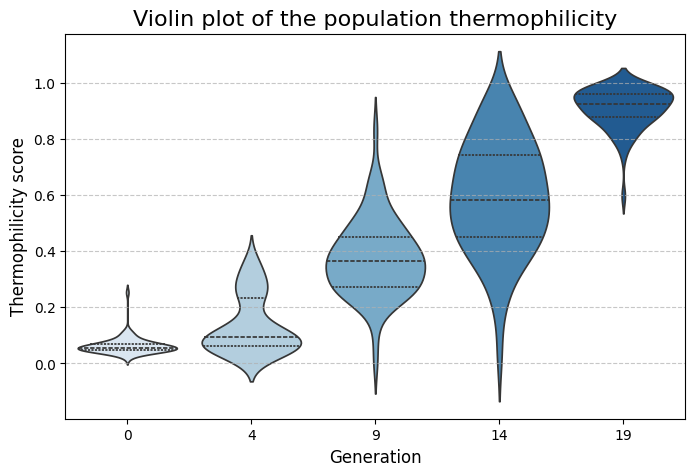

In [14]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_filtered, 
    x='generation', 
    y='fitness',
    palette='Blues', 
    inner='quartile'   
)

plt.title('Violin plot of the population thermophilicity', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Thermophilicity score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [9]:
final_generation = 19
caminho_final = os.path.join(path, f'generation_{final_generation}.json')
sequencias_finais = []

In [10]:
with open(caminho_final, 'r') as f:
    data = json.load(f)
    if 'population' in data and all('sequence' in ind for ind in data['population']):
        sequencias_finais = [ind['sequence'] for ind in data['population']]

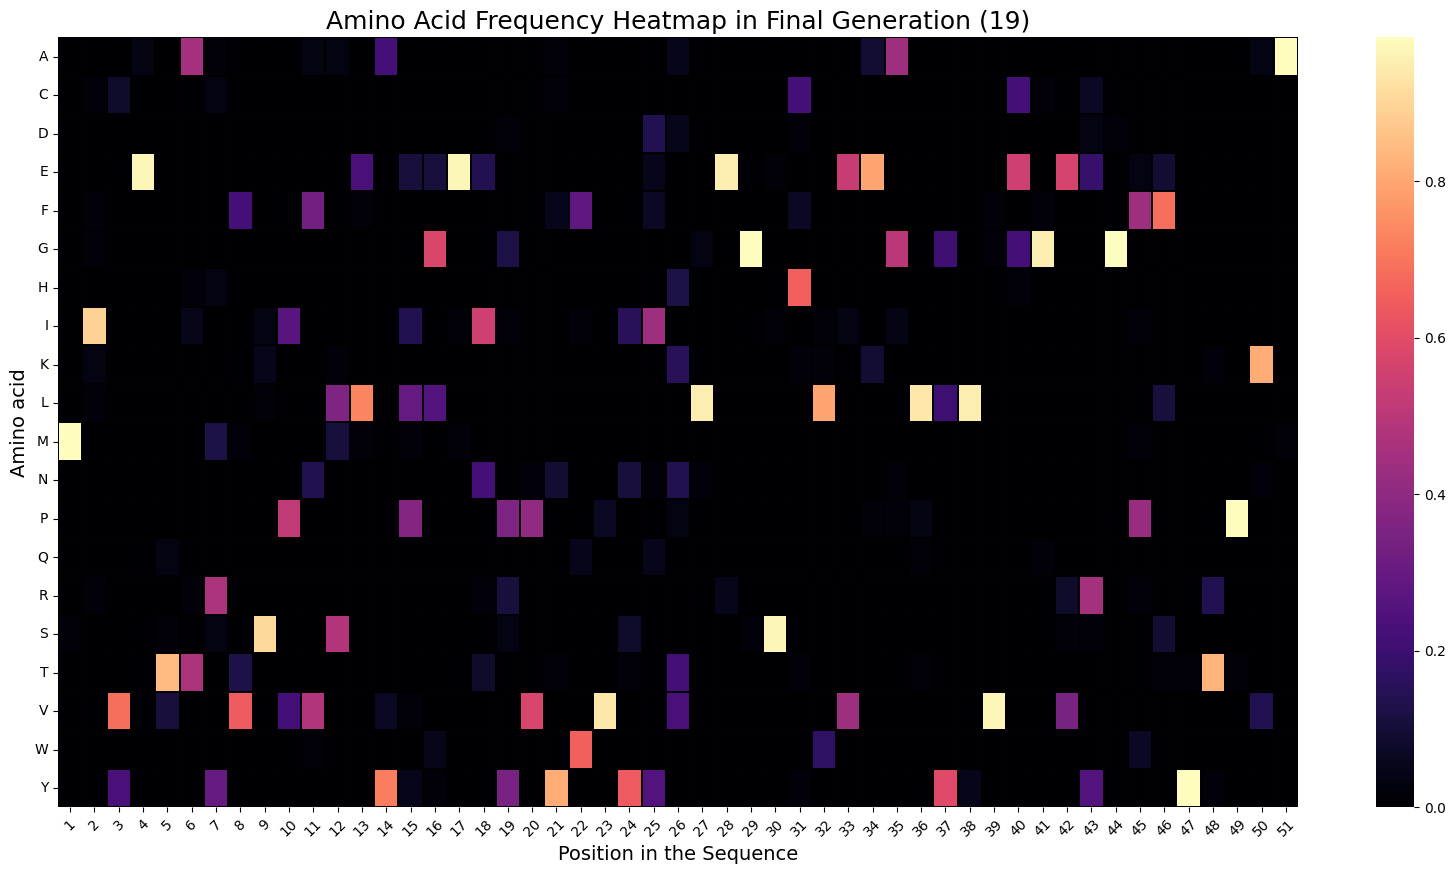

In [11]:
aminoacidos = sorted("ACDEFGHIKLMNPQRSTVWY")
comprimento_sequencia = len(sequencias_finais[0])

    # Cria um DataFrame do Pandas para ser nossa matriz, inicializado com zeros
matriz_frequencia = pd.DataFrame(0, index=aminoacidos, columns=range(1, comprimento_sequencia + 1))

    # Preenche a matriz com a contagem de cada aminoácido em cada posição
for seq in sequencias_finais:
        # Garante que a sequência tenha o comprimento esperado antes de processar
    if len(seq) == comprimento_sequencia:
        for i, aa in enumerate(seq):
            if aa in aminoacidos:
                    # Incrementa a contagem para aquele aminoácido naquela posição
                matriz_frequencia.loc[aa, i + 1] += 1

    # Normaliza a matriz pela quantidade de indivíduos para obter a frequência (de 0 a 1)
matriz_frequencia = matriz_frequencia / len(sequencias_finais)

    # --- Etapa 3: Plotar o Heatmap ---
plt.figure(figsize=(20, 10)) # Ajustando o tamanho para melhor visualização

sns.heatmap(
        data=matriz_frequencia,
        cmap='magma',  # 'magma' é uma ótima paleta que vai de escuro (baixa freq) a claro (alta freq)
        linewidths=.2,
        linecolor='black'
    )

plt.title(f'Amino Acid Frequency Heatmap in Final Generation ({final_generation})', fontsize=18)
plt.xlabel('Position in the Sequence', fontsize=14)
plt.ylabel('Amino acid', fontsize=14)
plt.xticks(rotation=45) # Rotaciona os labels do eixo x para não sobrepor
plt.yticks(rotation=0)  # Mantém os labels do eixo y na horizontal
plt.show()
